# Time Comparison: `cloelib` vs `pyccl`

This notebook benchmarks the computation of angular power spectra $C_\ell$ (GG, GE, EE) using two codes:
- **cloelib** (`HMemuNonLinearPerturbations` + `AngularTwoPoint`)
- **pyccl** (`halofit` + `ccl.angular_cl`)

We use the Euclid SPV3 photometric redshift distributions from `nzTabSPV3.fits`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import timeit
from scipy import integrate

import euclidlib as el

# cloelib
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint

# pyccl
import pyccl as ccl

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)
plt.rc('lines', linewidth=2)
plt.rc('legend', fontsize=12)

/Users/guadalupecanasherrera/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Load and prepare $n(z)$ from `nzTabSPV3.fits`

Number of bins: 13
Redshift range: 0.000 – 6.000,  n_z = 3001


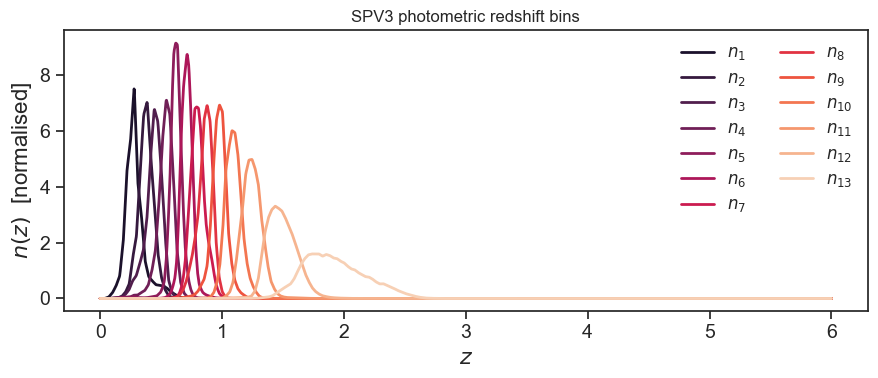

In [2]:
NZ_FILE = "nzTabSPV3.fits" #

# euclidlib reads the FITS file into z array + dict of per-bin n(z) arrays
z_nz, nz_spv3 = el.phz.redshift_distributions(NZ_FILE)

n_bins = len(nz_spv3)
print(f"Number of bins: {n_bins}")
print(f"Redshift range: {z_nz.min():.3f} – {z_nz.max():.3f},  n_z = {len(z_nz)}")

# Normalise n(z) so that ∫n(z)dz = 1
def normalize_dndz(nz_dict, z):
    return {k: v / integrate.trapezoid(v, z) for k, v in nz_dict.items()}

dndz_norm = normalize_dndz(nz_spv3, z_nz)

# Resample onto a uniform z grid used by cloelib
zs = np.linspace(1e-4, 3.0, 100)

def resample_dndz(nz_dict, z_src, z_tgt):
    stacked = np.vstack(list(nz_dict.values()))
    out = np.zeros((len(nz_dict), len(z_tgt)))
    for i in range(len(nz_dict)):
        out[i] = np.interp(z_tgt, z_src, stacked[i])
    return out

my_dndz_norm = resample_dndz(dndz_norm, z_nz, zs)

# Quick plot
colors = sns.color_palette("rocket", n_bins)
plt.figure(figsize=(9, 4))
for i, (key, col) in enumerate(zip(dndz_norm, colors)):
    plt.plot(z_nz, dndz_norm[key], color=col, label=f'$n_{{{i+1}}}$')
plt.xlabel(r'$z$')
plt.ylabel(r'$n(z)$  [normalised]')
plt.title('SPV3 photometric redshift bins')
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## `cloelib` — cosmology, tracers and $C_\ell$ function

In [3]:
background = CAMBBackground(
    H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
    w0=-1.0, wa=0.0, Omega_k0=0.0,
    ns=0.96, As=2e-9, mnu=0.06,
    gamma_MG=0.545, N_mnu=1,
)
linear_pert  = HMemuLinearPerturbations(background, zs)
nonlin_pert  = HMemuNonLinearPerturbations(background, linear_pert, zs, log10TAGN=7.8)

ells = np.arange(2, 3000)

# Nuisance params — zero shifts, unit width, flat bias
nuisance_pos = {
    'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0,
    'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
    **{f'magnification_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
    **{f'dz_pos_{i}': 0.0 for i in range(1, n_bins + 1)},
    **{f'width_pos_{i}': 1.0 for i in range(1, n_bins + 1)},
}
nuisance_she = {
    'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
    **{f'multiplicative_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
    **{f'dz_shear_{i}': 0.0 for i in range(1, n_bins + 1)},
    **{f'width_shear_{i}': 1.0 for i in range(1, n_bins + 1)},
}

tracer_pos_cl = PositionsTracer(
    perturbations=nonlin_pert, dndz=my_dndz_norm,
    z=zs, galaxy_bias_model='poly', nuisance_params=nuisance_pos,
)
tracer_she_cl = ShearTracer(
    perturbations=nonlin_pert, dndz=my_dndz_norm,
    z=zs, nuisance_params=nuisance_she,
)

tp_gg = AngularTwoPoint(tracer_pos_cl, tracer_pos_cl)
tp_ge = AngularTwoPoint(tracer_pos_cl, tracer_she_cl)
tp_ee = AngularTwoPoint(tracer_she_cl, tracer_she_cl)

def compute_cls_cloelib():
    cells = {}
    cells.update(tp_gg.get_Cl(ells, 0, nonlin_pert.k))
    cells.update(tp_ge.get_Cl(ells, 0, nonlin_pert.k))
    cells.update(tp_ee.get_Cl(ells, 0, nonlin_pert.k))
    return cells

print("cloelib setup done")

cloelib setup done


## `pyccl` — cosmology, tracers and $C_\ell$ function

In [4]:
cosmo_ccl = ccl.Cosmology(
    h=0.70, Omega_c=0.25, Omega_b=0.05,
    w0=-1.0, wa=0.0, n_s=0.96, A_s=2e-9,
    m_nu=0.06, Omega_k=0.0,
    matter_power_spectrum='halofit',
)

# Pre-compute the power spectrum once
cosmo_ccl.compute_nonlin_power()

AIA, CIA, EtaIA = 1.72, 0.0134, -0.41
ia_bias = AIA * CIA * (1.0 + z_nz) ** EtaIA

tracers_pos_ccl = [
    ccl.NumberCountsTracer(
        cosmo_ccl,
        dndz=(z_nz, dndz_norm[k]),
        bias=(z_nz, np.ones_like(z_nz)),
        has_rsd=False,
    )
    for k in dndz_norm
]
tracers_she_ccl = [
    ccl.WeakLensingTracer(
        cosmo_ccl,
        dndz=(z_nz, dndz_norm[k]),
        ia_bias=(z_nz, ia_bias),
    )
    for k in dndz_norm
]

ells_ccl = np.arange(2, 3000)

def compute_cls_ccl():
    cls = {}
    # Use 'fkem' integration method (faster than default 'limber' for many ells)
    for i in range(n_bins):
        for j in range(i, n_bins):
            cls['GG', i, j] = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[i], tracers_pos_ccl[j], ells_ccl, limber_integration_method='spline')
        for j in range(n_bins):
            cls['GE', i, j] = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[i], tracers_she_ccl[j], ells_ccl, limber_integration_method='spline')
        for j in range(i, n_bins):
            cls['EE', i, j] = ccl.angular_cl(cosmo_ccl, tracers_she_ccl[i], tracers_she_ccl[j], ells_ccl, limber_integration_method='spline')
    return cls

print("pyccl setup done")

pyccl setup done


## Timing sweep over $n_z$ and $n_\ell$

We sweep over:
- **`n_z`** — number of points in the cloelib redshift integration grid  
- **`n_ell`** — number of $\ell$ values passed to both codes  

For each combination we record the median wall-clock time over `N_REPEAT` runs.  
The pyccl tracers use the native `z_nz` grid from the FITS file, so `n_z` only affects cloelib.

In [5]:
N_REPEAT = 3  # timing runs per configuration

# Grid of parameters to sweep
nz_values   = [100, 1000, 4000]            # cloelib z-grid sizes
nell_values = [20]  # ell array lengths

# Results storage:  results[code][n_z][n_ell] = median time in seconds
results_cl  = {nz: {} for nz in nz_values}   # cloelib
results_ccl = {nz: {} for nz in nz_values}   # pyccl (same n_z key for alignment)

for nz in nz_values:
    print(f"\n── n_z = {nz} ─────────────────────")
    
    # ── cloelib: rebuild perturbations + tracers for this z-grid ──
    zs_sweep = np.linspace(1e-4, 3.0, nz)
    my_dndz_nz = resample_dndz(dndz_norm, z_nz, zs_sweep)

    bg     = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                            w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                            mnu=0.06, gamma_MG=0.545, N_mnu=1)
    lin    = HMemuLinearPerturbations(bg, zs_sweep)
    nonlin = HMemuNonLinearPerturbations(bg, lin, zs_sweep, log10TAGN=7.8)

    nuis_p = {'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0,
              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
              **{f'magnification_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
              **{f'dz_pos_{i}': 0.0 for i in range(1, n_bins + 1)},
              **{f'width_pos_{i}': 1.0 for i in range(1, n_bins + 1)}}
    nuis_s = {'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
              **{f'multiplicative_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
              **{f'dz_shear_{i}': 0.0 for i in range(1, n_bins + 1)},
              **{f'width_shear_{i}': 1.0 for i in range(1, n_bins + 1)}}

    tr_pos = PositionsTracer(perturbations=nonlin, dndz=my_dndz_nz, z=zs_sweep,
                             galaxy_bias_model='poly', nuisance_params=nuis_p)
    tr_she = ShearTracer(perturbations=nonlin, dndz=my_dndz_nz, z=zs_sweep,
                         nuisance_params=nuis_s)
    tp_gg_ = AngularTwoPoint(tr_pos, tr_pos)
    tp_ge_ = AngularTwoPoint(tr_pos, tr_she)
    tp_ee_ = AngularTwoPoint(tr_she, tr_she)

    for nell in nell_values:
        ells_sweep = np.unique(np.geomspace(2, 2999, nell).astype(int))

        # cloelib timing
        def _cl():
            c = {}
            c.update(tp_gg_.get_Cl(ells_sweep, 0, nonlin.k))
            c.update(tp_ge_.get_Cl(ells_sweep, 0, nonlin.k))
            c.update(tp_ee_.get_Cl(ells_sweep, 0, nonlin.k))
            return c

        t_cl = timeit.repeat(_cl, repeat=N_REPEAT, number=1)
        results_cl[nz][nell] = np.median(t_cl)

        # pyccl timing (tracers fixed; only ell array varies)
        def _ccl():
            cls = {}
            for i in range(n_bins):
                for j in range(i, n_bins):
                    cls['GG', i, j] = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[i],
                                                      tracers_pos_ccl[j], ells_sweep,
                                                      limber_integration_method='qag_quad')
                for j in range(n_bins):
                    cls['GE', i, j] = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[i],
                                                      tracers_she_ccl[j], ells_sweep,
                                                      limber_integration_method='qag_quad')
                for j in range(i, n_bins):
                    cls['EE', i, j] = ccl.angular_cl(cosmo_ccl, tracers_she_ccl[i],
                                                      tracers_she_ccl[j], ells_sweep,
                                                      limber_integration_method='spline')
            return cls

        t_ccl = timeit.repeat(_ccl, repeat=N_REPEAT, number=1)
        results_ccl[nz][nell] = np.median(t_ccl)

        print(f"  n_ell={nell:5d} | cloelib {results_cl[nz][nell]:.2f}s  "
              f"pyccl {results_ccl[nz][nell]:.2f}s  "
              f"ratio {results_cl[nz][nell]/results_ccl[nz][nell]:.2f}x")

print("\nSweep complete.")


── n_z = 100 ─────────────────────
  n_ell=   20 | cloelib 0.13s  pyccl 0.45s  ratio 0.28x

── n_z = 1000 ─────────────────────
  n_ell=   20 | cloelib 0.36s  pyccl 0.44s  ratio 0.83x

── n_z = 4000 ─────────────────────
  n_ell=   20 | cloelib 1.16s  pyccl 0.48s  ratio 2.45x

Sweep complete.


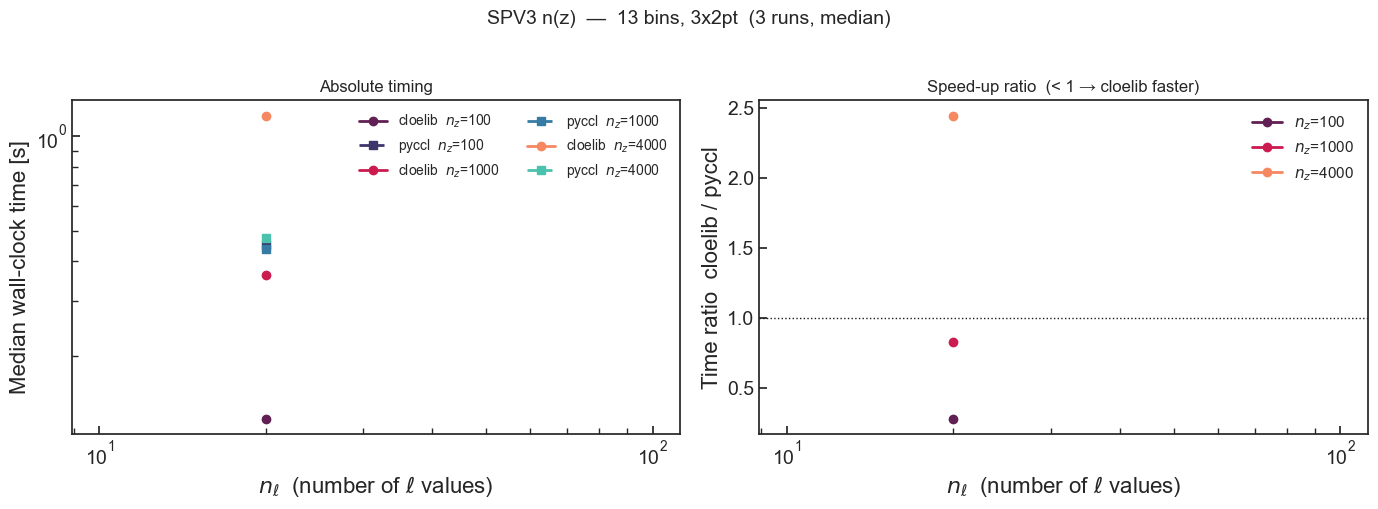

In [6]:
pal_cl  = sns.color_palette("rocket",  len(nz_values))
pal_ccl = sns.color_palette("mako",    len(nz_values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax_t, ax_r = axes
nell_arr = np.array(nell_values)

for idx, nz in enumerate(nz_values):
    t_cl_arr  = np.array([results_cl[nz][n]  for n in nell_values])
    t_ccl_arr = np.array([results_ccl[nz][n] for n in nell_values])
    ratio_arr = t_cl_arr / t_ccl_arr

    ax_t.plot(nell_arr, t_cl_arr,  color=pal_cl[idx],  lw=2,
              marker='o', label=f'cloelib  $n_z$={nz}')
    ax_t.plot(nell_arr, t_ccl_arr, color=pal_ccl[idx], lw=2,
              marker='s', ls='--', label=f'pyccl  $n_z$={nz}')

    ax_r.plot(nell_arr, ratio_arr, color=pal_cl[idx], lw=2,
              marker='o', label=f'$n_z$={nz}')

ax_t.set_xlabel(r'$n_\ell$  (number of $\ell$ values)')
ax_t.set_ylabel('Median wall-clock time [s]')
ax_t.set_title('Absolute timing')
ax_t.set_xscale('log')
ax_t.set_yscale('log')
ax_t.legend(fontsize=10, frameon=False, ncol=2)
ax_t.tick_params(axis='both', which='both', direction='in')

ax_r.axhline(1.0, color='k', lw=1, ls=':')
ax_r.set_xlabel(r'$n_\ell$  (number of $\ell$ values)')
ax_r.set_ylabel('Time ratio  cloelib / pyccl')
ax_r.set_title('Speed-up ratio  (< 1 → cloelib faster)')
ax_r.set_xscale('log')
ax_r.legend(fontsize=11, frameon=False)
ax_r.tick_params(axis='both', which='both', direction='in')

plt.suptitle(f'SPV3 n(z)  —  {n_bins} bins, 3x2pt  ({N_REPEAT} runs, median)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('time_comparison_SPV3_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Timing as a function of number of redshift bins

Fixed settings: **`n_z = 200`**, **`n_ell = 100`** (log-spaced).  
We progressively use the first `n_b` bins from the full 13-bin SPV3 n(z), and time the complete GG + GE + EE computation for both codes.  
The number of spectra scales as $n_b(2n_b+1)$, so we expect roughly quadratic scaling.

In [7]:
NZ_BINS   = 150    # fixed z-grid size for cloelib
NELL_BINS = 20    # fixed number of ell values

# Bin counts to sweep (up to the total available)
max_bins = len(dndz_norm)
nbin_values = [b for b in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] if b <= max_bins]

print(f"Total bins in file: {max_bins}")
print(f"Sweeping n_bins = {nbin_values}\n")

ells_bins  = np.unique(np.geomspace(2, 2999, NELL_BINS).astype(int))
zs_bins    = np.linspace(1e-4, 3.0, NZ_BINS)

# Pre-build cloelib perturbations once (z-grid fixed)
bg_b   = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                        w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                        mnu=0.06, gamma_MG=0.545, N_mnu=1)
lin_b  = HMemuLinearPerturbations(bg_b, zs_bins)
nlin_b = HMemuNonLinearPerturbations(bg_b, lin_b, zs_bins, log10TAGN=7.8)

# Results storage
results_bins_cl  = {}
results_bins_ccl = {}

all_keys = list(dndz_norm.keys())

for nb in nbin_values:
    keys_nb  = all_keys[:nb]
    dndz_nb  = {k: dndz_norm[k] for k in keys_nb}
    dndz_nb_resampled = resample_dndz(dndz_nb, z_nz, zs_bins)

    # ── cloelib ──
    nuis_p_b = {'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0,
                'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                **{f'magnification_bias_{i}': 0.0 for i in range(1, nb + 1)},
                **{f'dz_pos_{i}': 0.0 for i in range(1, nb + 1)},
                **{f'width_pos_{i}': 1.0 for i in range(1, nb + 1)}}
    nuis_s_b = {'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
                **{f'multiplicative_bias_{i}': 0.0 for i in range(1, nb + 1)},
                **{f'dz_shear_{i}': 0.0 for i in range(1, nb + 1)},
                **{f'width_shear_{i}': 1.0 for i in range(1, nb + 1)}}

    tr_p_b = PositionsTracer(perturbations=nlin_b, dndz=dndz_nb_resampled,
                             z=zs_bins, galaxy_bias_model='poly', nuisance_params=nuis_p_b)
    tr_s_b = ShearTracer(perturbations=nlin_b, dndz=dndz_nb_resampled,
                         z=zs_bins, nuisance_params=nuis_s_b)
    gg_b = AngularTwoPoint(tr_p_b, tr_p_b)
    ge_b = AngularTwoPoint(tr_p_b, tr_s_b)
    ee_b = AngularTwoPoint(tr_s_b, tr_s_b)

    def _cl_bins():
        c = {}
        c.update(gg_b.get_Cl(ells_bins, 0, nlin_b.k))
        c.update(ge_b.get_Cl(ells_bins, 0, nlin_b.k))
        c.update(ee_b.get_Cl(ells_bins, 0, nlin_b.k))
        return c

    results_bins_cl[nb] = np.median(timeit.repeat(_cl_bins, repeat=N_REPEAT, number=1))

    # ── pyccl ──
    ia_bias_b = AIA * CIA * (1.0 + z_nz) ** EtaIA
    tr_pos_ccl_b = [
        ccl.NumberCountsTracer(cosmo_ccl, dndz=(z_nz, dndz_nb[k]),
                               bias=(z_nz, np.ones_like(z_nz)), has_rsd=False)
        for k in keys_nb
    ]
    tr_she_ccl_b = [
        ccl.WeakLensingTracer(cosmo_ccl, dndz=(z_nz, dndz_nb[k]),
                              ia_bias=(z_nz, ia_bias_b))
        for k in keys_nb
    ]

    def _ccl_bins():
        cls = {}
        for i in range(nb):
            for j in range(i, nb):
                cls['GG', i, j] = ccl.angular_cl(cosmo_ccl, tr_pos_ccl_b[i],
                                                  tr_pos_ccl_b[j], ells_bins,
                                                  limber_integration_method='qag_quad')
            for j in range(nb):
                cls['GE', i, j] = ccl.angular_cl(cosmo_ccl, tr_pos_ccl_b[i],
                                                  tr_she_ccl_b[j], ells_bins,
                                                  limber_integration_method='qag_quad')
            for j in range(i, nb):
                cls['EE', i, j] = ccl.angular_cl(cosmo_ccl, tr_she_ccl_b[i],
                                                  tr_she_ccl_b[j], ells_bins,
                                                  limber_integration_method='qag_quad')
        return cls

    results_bins_ccl[nb] = np.median(timeit.repeat(_ccl_bins, repeat=N_REPEAT, number=1))

    n_spectra = nb * (2 * nb + 1)
    print(f"  n_bins={nb:2d}  ({n_spectra:3d} spectra) | "
          f"cloelib {results_bins_cl[nb]:.2f}s  "
          f"pyccl {results_bins_ccl[nb]:.2f}s  "
          f"ratio {results_bins_cl[nb]/results_bins_ccl[nb]:.2f}x")

print("\nBin sweep complete.")

Total bins in file: 13
Sweeping n_bins = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

  n_bins= 1  (  3 spectra) | cloelib 0.02s  pyccl 0.00s  ratio 8.50x
  n_bins= 2  ( 10 spectra) | cloelib 0.02s  pyccl 0.01s  ratio 2.54x
  n_bins= 3  ( 21 spectra) | cloelib 0.03s  pyccl 0.02s  ratio 1.39x
  n_bins= 4  ( 36 spectra) | cloelib 0.03s  pyccl 0.03s  ratio 0.94x
  n_bins= 5  ( 55 spectra) | cloelib 0.04s  pyccl 0.06s  ratio 0.61x
  n_bins= 6  ( 78 spectra) | cloelib 0.05s  pyccl 0.09s  ratio 0.50x
  n_bins= 7  (105 spectra) | cloelib 0.05s  pyccl 0.14s  ratio 0.36x
  n_bins= 8  (136 spectra) | cloelib 0.06s  pyccl 0.16s  ratio 0.38x
  n_bins= 9  (171 spectra) | cloelib 0.07s  pyccl 0.19s  ratio 0.37x
  n_bins=10  (210 spectra) | cloelib 0.08s  pyccl 0.22s  ratio 0.37x
  n_bins=11  (253 spectra) | cloelib 0.10s  pyccl 0.28s  ratio 0.34x
  n_bins=12  (300 spectra) | cloelib 0.11s  pyccl 0.32s  ratio 0.33x
  n_bins=13  (351 spectra) | cloelib 0.13s  pyccl 0.39s  ratio 0.32x

Bin sweep comple

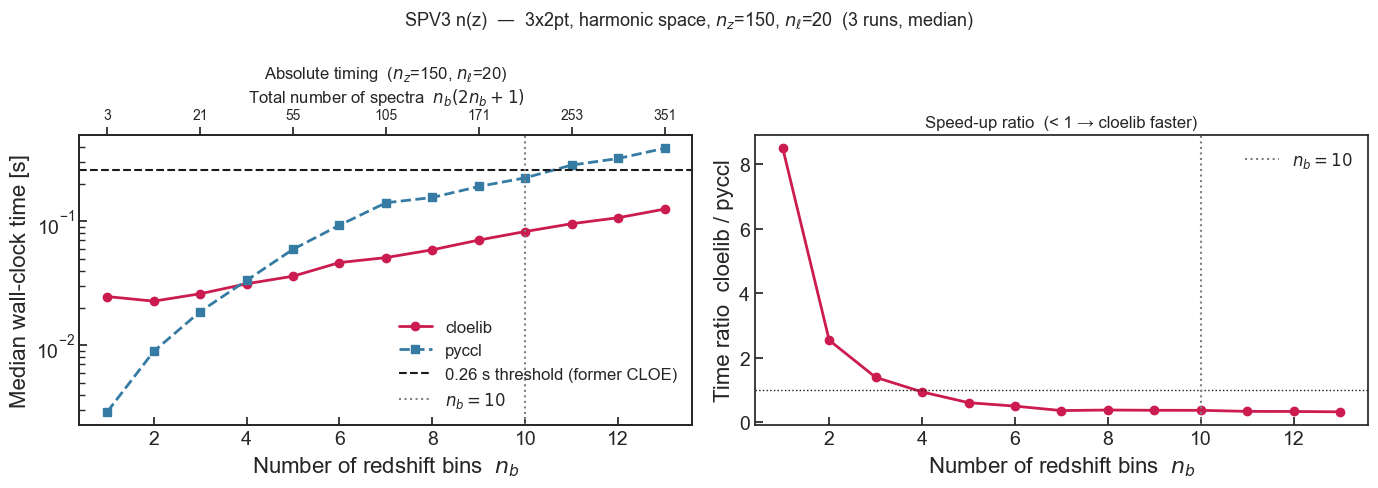

In [8]:
nbin_arr   = np.array(nbin_values)
t_cl_bins  = np.array([results_bins_cl[nb]  for nb in nbin_values])
t_ccl_bins = np.array([results_bins_ccl[nb] for nb in nbin_values])
ratio_bins = t_cl_bins / t_ccl_bins
n_spectra_arr = nbin_arr * (2 * nbin_arr + 1)

quad_ref = n_spectra_arr**2 / n_spectra_arr[0]**2 * t_cl_bins[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_t, ax_r = axes

col_cl  = sns.color_palette("rocket", 3)[1]
col_ccl = sns.color_palette("mako",   3)[1]

ax_t.plot(nbin_arr, t_cl_bins,  color=col_cl,  lw=2, marker='o', label='cloelib')
ax_t.plot(nbin_arr, t_ccl_bins, color=col_ccl, lw=2, marker='s', ls='--', label='pyccl')
ax_t.axhline(0.26, color='k', lw=1.5, ls='--', label='0.26 s threshold (former CLOE)')
ax_t.axvline(10, color='grey', lw=1.5, ls=':', label='$n_b=10$')
ax_t.set_xlabel('Number of redshift bins  $n_b$')
ax_t.set_ylabel('Median wall-clock time [s]')
ax_t.set_title(f'Absolute timing  ($n_z$={NZ_BINS}, $n_\\ell$={NELL_BINS})')
ax_t.set_yscale('log')
ax_t.legend(frameon=False)
ax_t.tick_params(axis='both', which='both', direction='in')

ax_top = ax_t.twiny()
ax_top.set_xlim(ax_t.get_xlim())
ax_top.set_xticks(nbin_arr[::2])
ax_top.set_xticklabels([str(n_spectra_arr[i]) for i in range(0, len(nbin_arr), 2)], fontsize=10)
ax_top.set_xlabel('Total number of spectra  $n_b(2n_b+1)$', fontsize=12)

ax_r.plot(nbin_arr, ratio_bins, color=col_cl, lw=2, marker='o')
ax_r.axhline(1.0, color='k', lw=1, ls=':')
ax_r.axvline(10, color='grey', lw=1.5, ls=':', label='$n_b=10$')
ax_r.set_xlabel('Number of redshift bins  $n_b$')
ax_r.set_ylabel('Time ratio  cloelib / pyccl')
ax_r.set_title('Speed-up ratio  (< 1 → cloelib faster)')
ax_r.tick_params(axis='both', which='both', direction='in')
ax_r.legend(frameon=False)

plt.suptitle(f'SPV3 n(z)  —  3x2pt, harmonic space, $n_z$={NZ_BINS}, $n_\\ell$={NELL_BINS}  ({N_REPEAT} runs, median)',
             fontsize=13)
plt.tight_layout()
plt.savefig('time_comparison_SPV3_bins.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import os
import threading
import time

print(f"OMP_NUM_THREADS = {os.environ.get('OMP_NUM_THREADS', 'not set')}")
print(f"MKL_NUM_THREADS = {os.environ.get('MKL_NUM_THREADS', 'not set')}")
print(f"OPENBLAS_NUM_THREADS = {os.environ.get('OPENBLAS_NUM_THREADS', 'not set')}")

active_threads = []

def monitor_threads(duration=5, interval=0.1):
    max_threads = 0
    t_end = time.time() + duration
    while time.time() < t_end:
        n = threading.active_count()
        if n > max_threads:
            max_threads = n
        time.sleep(interval)
    return max_threads

# Run cloelib computation while monitoring thread count
monitor_results = []

def run_monitor():
    monitor_results.append(monitor_threads(duration=10, interval=0.05))

monitor_thread = threading.Thread(target=run_monitor)
monitor_thread.start()

# Run a cloelib computation
start = time.time()
_ = tp_gg.get_Cl(ells, 0, nonlin_pert.k)
elapsed = time.time() - start

monitor_thread.join()

print(f"\ncloelib get_Cl took {elapsed:.2f}s")
print(f"Max active Python threads observed during run: {monitor_results[0]}")
print(f"(baseline idle threads: {threading.active_count()})")
print("\nNote: Python thread count only detects Python-level threads.")
print("Use 'htop' or 'ps -eLf' during execution to detect native/OMP threads.")

OMP_NUM_THREADS = not set
MKL_NUM_THREADS = not set
OPENBLAS_NUM_THREADS = not set

cloelib get_Cl took 1.07s
Max active Python threads observed during run: 10
(baseline idle threads: 9)

Note: Python thread count only detects Python-level threads.
Use 'htop' or 'ps -eLf' during execution to detect native/OMP threads.


In [10]:
import os
import subprocess
import time
import threading

# Check OpenMP-related environment variables
print("=== Environment Variables ===")
for var in ['OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS']:
    print(f"{var} = {os.environ.get(var, 'not set')}")

# Try to detect number of threads used by pyccl via /proc (Linux only)
def count_threads_pid(pid):
    try:
        with open(f'/proc/{pid}/status') as f:
            for line in f:
                if line.startswith('Threads:'):
                    return int(line.split()[1])
    except Exception:
        return None

pid = os.getpid()
baseline_threads = count_threads_pid(pid)
print(f"\n=== Thread count (via /proc) ===")
print(f"Baseline threads before pyccl call: {baseline_threads}")

# Monitor threads in background while running pyccl
max_threads_observed = [baseline_threads or 0]

def monitor():
    t_end = time.time() + 30
    while time.time() < t_end:
        n = count_threads_pid(pid)
        if n and n > max_threads_observed[0]:
            max_threads_observed[0] = n
        time.sleep(0.01)

mon = threading.Thread(target=monitor, daemon=True)
mon.start()

# Run a moderately expensive pyccl computation
print("\nRunning pyccl angular_cl to probe thread usage...")
t0 = time.time()
_ = ccl.angular_cl(cosmo_ccl, tracers_pos_ccl[0], tracers_she_ccl[-1],
                   np.arange(2, 3000), limber_integration_method='qag_quad')
elapsed = time.time() - t0

mon.join(timeout=1)

print(f"pyccl angular_cl took {elapsed:.3f}s")
print(f"Max threads observed during run: {max_threads_observed[0]}  (baseline: {baseline_threads})")

# Also try via `ps` for native thread count
try:
    result = subprocess.run(['ps', '-o', 'nlwp=', '-p', str(pid)],
                            capture_output=True, text=True)
    print(f"Native threads (ps nlwp): {result.stdout.strip()}")
except Exception as e:
    print(f"ps query failed: {e}")

# Check if pyccl was compiled with OMP
try:
    import pyccl._core as _cc
    print(f"\npyccl version: {ccl.__version__}")
except Exception:
    pass

print("\nNote: if max_threads > baseline, pyccl is spawning native OMP/pthreads.")

=== Environment Variables ===
OMP_NUM_THREADS = not set
MKL_NUM_THREADS = not set
OPENBLAS_NUM_THREADS = not set
NUMEXPR_NUM_THREADS = not set

=== Thread count (via /proc) ===
Baseline threads before pyccl call: None

Running pyccl angular_cl to probe thread usage...
pyccl angular_cl took 0.144s
Max threads observed during run: 0  (baseline: None)
Native threads (ps nlwp): %cpu %mem acflag acflg args blocked comm command cpu cputime etime f flags gid
group inblk inblock jobc ktrace ktracep lim login logname lstart majflt minflt
msgrcv msgsnd ni nice nivcsw nsignals nsigs nswap nvcsw nwchan oublk oublock
p_ru paddr pagein pcpu pending pgid pid pmem ppid pri prsna pstime putime re
rgid rgroup rss ruid ruser sess sig sigmask sl start stat state stime svgid
svuid tdev time tpgid tsess tsiz tt tty ucomm uid upr user usrpri utime vsize
vsz wchan wq wqb wql wqr xstat

pyccl version: 3.3.1

Note: if max_threads > baseline, pyccl is spawning native OMP/pthreads.


## Former CLOE vs `cloelib` — ell scaling

Timing comparison using matched conditions: **13 redshift bins**, **`n_z = 100`**, **`n_k = 1000`** (cloelib internal), sweeping over $n_\ell \in \{20, 32, 100, 500, 1000, 3000\}$.

Former CLOE timings come from a standalone benchmark run (3x2pt, harmonic space, SPV3 cosmology).

In [11]:
# ── Former CLOE timings (100 z, 1000 k, 13 bins) ────────────────────────────
former_cloe_nell   = np.array([20, 32, 100, 500, 1000, 3000])
former_cloe_time_s = np.array([0.421744, 0.500777, 1.177449, 5.702822, 11.646631, 36.621765])

# ── cloelib benchmark: nz=100, all 13 SPV3 bins, same ell values ─────────────
NZ_CLOE_COMP = 100
N_REPEAT_COMP = 3

zs_comp      = np.linspace(1e-4, 3.0, NZ_CLOE_COMP)
my_dndz_comp = resample_dndz(dndz_norm, z_nz, zs_comp)

bg_comp     = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                              w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                              mnu=0.06, gamma_MG=0.545, N_mnu=1)
lin_comp    = HMemuLinearPerturbations(bg_comp, zs_comp)
nonlin_comp = HMemuNonLinearPerturbations(bg_comp, lin_comp, zs_comp, log10TAGN=7.8)

nuis_p_comp = {'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0,
               'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
               **{f'magnification_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
               **{f'dz_pos_{i}': 0.0 for i in range(1, n_bins + 1)},
               **{f'width_pos_{i}': 1.0 for i in range(1, n_bins + 1)}}
nuis_s_comp = {'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
               **{f'multiplicative_bias_{i}': 0.0 for i in range(1, n_bins + 1)},
               **{f'dz_shear_{i}': 0.0 for i in range(1, n_bins + 1)},
               **{f'width_shear_{i}': 1.0 for i in range(1, n_bins + 1)}}

tr_pos_comp = PositionsTracer(perturbations=nonlin_comp, dndz=my_dndz_comp,
                               z=zs_comp, galaxy_bias_model='poly',
                               nuisance_params=nuis_p_comp)
tr_she_comp = ShearTracer(perturbations=nonlin_comp, dndz=my_dndz_comp,
                          z=zs_comp, nuisance_params=nuis_s_comp)
tp_gg_comp  = AngularTwoPoint(tr_pos_comp, tr_pos_comp)
tp_ge_comp  = AngularTwoPoint(tr_pos_comp, tr_she_comp)
tp_ee_comp  = AngularTwoPoint(tr_she_comp, tr_she_comp)

cloelib_comp_times = {}
for nell in former_cloe_nell:
    ells_comp = np.unique(np.geomspace(2, 2999, nell).astype(int))

    def _cl_comp():
        c = {}
        c.update(tp_gg_comp.get_Cl(ells_comp, 0, nonlin_comp.k))
        c.update(tp_ge_comp.get_Cl(ells_comp, 0, nonlin_comp.k))
        c.update(tp_ee_comp.get_Cl(ells_comp, 0, nonlin_comp.k))
        return c

    times = timeit.repeat(_cl_comp, repeat=N_REPEAT_COMP, number=1)
    cloelib_comp_times[nell] = np.median(times)
    print(f"  n_ell={nell:5d} | cloelib {cloelib_comp_times[nell]:.3f}s  "
          f"  former CLOE {former_cloe_time_s[former_cloe_nell == nell][0]:.3f}s  "
          f"  ratio cloelib/CLOE {cloelib_comp_times[nell] / former_cloe_time_s[former_cloe_nell == nell][0]:.2f}x")

print("\nBenchmark complete.")


  n_ell=   20 | cloelib 0.120s    former CLOE 0.422s    ratio cloelib/CLOE 0.28x
  n_ell=   32 | cloelib 0.124s    former CLOE 0.501s    ratio cloelib/CLOE 0.25x
  n_ell=  100 | cloelib 0.138s    former CLOE 1.177s    ratio cloelib/CLOE 0.12x
  n_ell=  500 | cloelib 0.135s    former CLOE 5.703s    ratio cloelib/CLOE 0.02x
  n_ell= 1000 | cloelib 0.142s    former CLOE 11.647s    ratio cloelib/CLOE 0.01x
  n_ell= 3000 | cloelib 0.161s    former CLOE 36.622s    ratio cloelib/CLOE 0.00x

Benchmark complete.


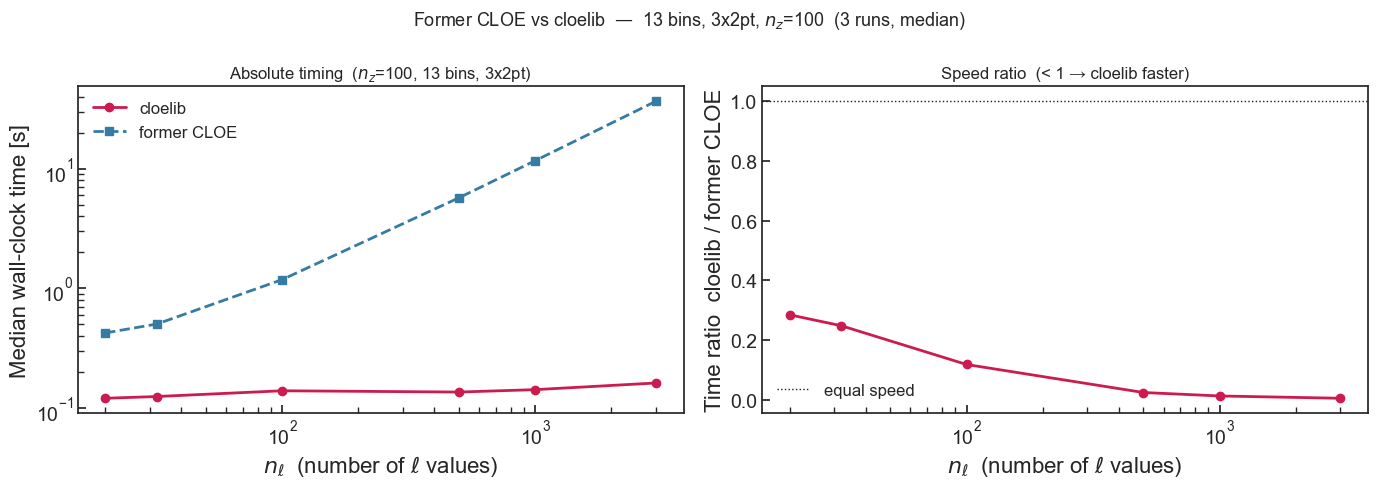

In [12]:
cloelib_time_arr = np.array([cloelib_comp_times[n] for n in former_cloe_nell])
ratio_arr        = cloelib_time_arr / former_cloe_time_s

col_cloelib = sns.color_palette("rocket", 3)[1]
col_cloe    = sns.color_palette("mako",   3)[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_t, ax_r = axes

ax_t.plot(former_cloe_nell, cloelib_time_arr, color=col_cloelib, lw=2,
          marker='o', label='cloelib')
ax_t.plot(former_cloe_nell, former_cloe_time_s, color=col_cloe, lw=2,
          marker='s', ls='--', label='former CLOE')

ax_t.set_xlabel(r'$n_\ell$  (number of $\ell$ values)')
ax_t.set_ylabel('Median wall-clock time [s]')
ax_t.set_title(f'Absolute timing  ($n_z$={NZ_CLOE_COMP}, 13 bins, 3x2pt)')
ax_t.set_xscale('log')
ax_t.set_yscale('log')
ax_t.legend(frameon=False)
ax_t.tick_params(axis='both', which='both', direction='in')

ax_r.plot(former_cloe_nell, ratio_arr, color=col_cloelib, lw=2, marker='o')
ax_r.axhline(1.0, color='k', lw=1, ls=':', label='equal speed')
ax_r.set_xlabel(r'$n_\ell$  (number of $\ell$ values)')
ax_r.set_ylabel('Time ratio  cloelib / former CLOE')
ax_r.set_title('Speed ratio  (< 1 → cloelib faster)')
ax_r.set_xscale('log')
ax_r.legend(frameon=False)
ax_r.tick_params(axis='both', which='both', direction='in')

plt.suptitle(f'Former CLOE vs cloelib  —  13 bins, 3x2pt, $n_z$={NZ_CLOE_COMP}  ({N_REPEAT_COMP} runs, median)',
             fontsize=13)
plt.tight_layout()
plt.savefig('time_comparison_cloe_vs_cloelib.png', dpi=150, bbox_inches='tight')
plt.show()


## Comparison on calling 3x2pt theory prediction through `cloelib` vs. `cloelike`

In [13]:
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt

# Minimal `data`/`settings` pair -- only what get_theory_vector_full needs.
# No observed cells/covariance/mixing matrix required since we never call loglike().
data_like = {
    'z_arr': zs,
    'dndz_pos': my_dndz_norm,
    'dndz_she': my_dndz_norm,
    'ells': ells,
}
settings_like = {'scale_cuts': {}}

like_3x2pt = EuclidLikelihood_3x2pt(
    data=data_like,
    settings=settings_like,
    Background=CAMBBackground,
    LinPerturbations=HMemuLinearPerturbations,
    NonLinPerturbations=HMemuNonLinearPerturbations,
    mode='uncoupled',  # un-mixed get_Cl path, matching the direct cloelib calls above
)

# parameters dict = cosmology + astrophysical/nuisance parameters expected
# by get_theory_vector_full (same fiducial values used for `nuisance_pos`/`nuisance_she` above)
parameters = {
    'H0': 70.0, 'Omega_cdm0': 0.25, 'Omega_b0': 0.05, 'Omega_k0': 0.0,
    'w0': -1.0, 'wa': 0.0, 'ns': 0.96, 'As': 2e-9, 'mnu': 0.06,
    'gamma_MG': 0.545, 'N_mnu': 1, 'log10TAGN': 7.8,
    **nuisance_pos, **nuisance_she,
}

print("cloelike EuclidLikelihood_3x2pt setup done")

cloelike EuclidLikelihood_3x2pt setup done


In [14]:
# ── Correctness check ──────────────────────────────────────────────────────
# theory_prediction stores the raw {(species, species, i, j): AngularPowerSpectrum}
# dict built internally by get_theory_vector_full -- compare it directly against
# the cells returned by the plain cloelib call `compute_cls_cloelib()`.
_ = like_3x2pt.get_theory_vector_full(parameters)
cells_direct = compute_cls_cloelib()
cells_wrapped = like_3x2pt.theory_prediction

common_keys = set(cells_direct) & set(cells_wrapped)
print(f"Compared {len(common_keys)} / {len(cells_direct)} spectra")

max_abs_diff = max(
    np.max(np.abs(np.asarray(cells_direct[k]) - np.asarray(cells_wrapped[k])))
    for k in common_keys
)
max_rel_diff = max(
    np.max(np.abs(np.asarray(cells_direct[k]) - np.asarray(cells_wrapped[k]))
           / np.clip(np.abs(np.asarray(cells_direct[k])), 1e-300, None))
    for k in common_keys
)
all_close = all(
    np.allclose(np.asarray(cells_direct[k]), np.asarray(cells_wrapped[k]))
    for k in common_keys
)

print(f"All spectra match (np.allclose): {all_close}")
print(f"Max absolute difference: {max_abs_diff:.3e}")
print(f"Max relative difference: {max_rel_diff:.3e}")

Compared 351 / 351 spectra
All spectra match (np.allclose): True
Max absolute difference: 0.000e+00
Max relative difference: 0.000e+00


In [15]:
# ── Timing comparison ───────────────────────────────────────────────────────
# get_theory_vector_full rebuilds Background/LinPerturbations/NonLinPerturbations
# (and the tracers) from scratch on every call -- required since `parameters` can
# change between calls in a sampler -- so a naive comparison against
# compute_cls_cloelib() (which reuses already-built tracers) isn't apples-to-apples.
# We therefore also time an equivalent direct pipeline that rebuilds everything too.
N_REPEAT_WRAP = 10

def compute_cls_cloelib_full_pipeline():
    """Rebuild background/perturbations/tracers from scratch each call, matching
    what get_theory_vector_full does internally -- for a fair timing comparison."""
    bg = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05,
                         w0=-1.0, wa=0.0, Omega_k0=0.0, ns=0.96, As=2e-9,
                         mnu=0.06, gamma_MG=0.545, N_mnu=1)
    lin = HMemuLinearPerturbations(bg, zs)
    nlin = HMemuNonLinearPerturbations(bg, lin, zs, log10TAGN=7.8)
    tr_pos = PositionsTracer(perturbations=nlin, dndz=my_dndz_norm, z=zs,
                              galaxy_bias_model='poly', nuisance_params=nuisance_pos)
    tr_she = ShearTracer(perturbations=nlin, dndz=my_dndz_norm, z=zs,
                          nuisance_params=nuisance_she)
    c = {}
    c.update(AngularTwoPoint(tr_pos, tr_pos).get_Cl(ells, 0, nlin.k))
    c.update(AngularTwoPoint(tr_pos, tr_she).get_Cl(ells, 0, nlin.k))
    c.update(AngularTwoPoint(tr_she, tr_she).get_Cl(ells, 0, nlin.k))
    return c

t_direct = timeit.repeat(compute_cls_cloelib, repeat=N_REPEAT_WRAP, number=1)
t_direct_full = timeit.repeat(compute_cls_cloelib_full_pipeline, repeat=N_REPEAT_WRAP, number=1)
t_wrapped = timeit.repeat(lambda: like_3x2pt.get_theory_vector_full(parameters),
                           repeat=N_REPEAT_WRAP, number=1)

med_direct = np.median(t_direct)
med_direct_full = np.median(t_direct_full)
med_wrapped = np.median(t_wrapped)

print(f"cloelib direct (tracers reused):      {med_direct:.3f}s")
print(f"cloelib direct (full pipeline):       {med_direct_full:.3f}s")
print(f"cloelike get_theory_vector_full:      {med_wrapped:.3f}s")
print()
print(f"Ratio wrapped / direct (naive, reused tracers): {med_wrapped / med_direct:.2f}x")
print(f"Ratio wrapped / direct (fair, full pipeline):   {med_wrapped / med_direct_full:.2f}x")

cloelib direct (tracers reused):      0.216s
cloelib direct (full pipeline):       0.292s
cloelike get_theory_vector_full:      0.215s

Ratio wrapped / direct (naive, reused tracers): 1.00x
Ratio wrapped / direct (fair, full pipeline):   0.73x


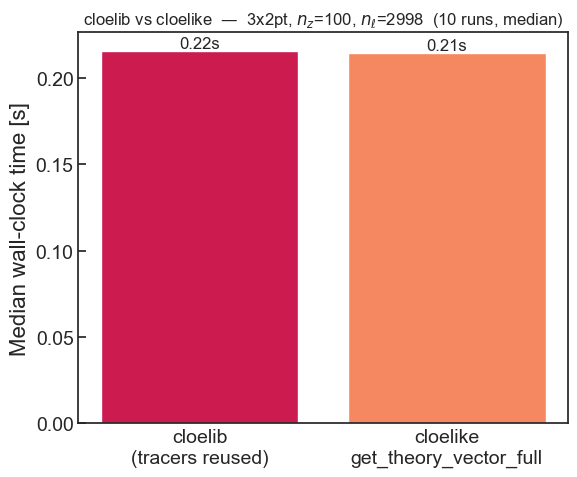

In [17]:
labels = ['cloelib\n(tracers reused)', 'cloelike\nget_theory_vector_full']
times = [med_direct, med_wrapped]
colors_bar = [sns.color_palette("rocket", 3)[1], sns.color_palette("rocket", 3)[2], sns.color_palette("mako", 3)[1]]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, times, color=colors_bar)
plt.ylabel('Median wall-clock time [s]')
plt.title(f'cloelib vs cloelike  —  3x2pt, $n_z$={len(zs)}, $n_\\ell$={len(ells)}  ({N_REPEAT_WRAP} runs, median)')
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{t:.2f}s',
              ha='center', va='bottom', fontsize=12)
plt.tick_params(axis='both', which='both', direction='in')
plt.tight_layout()
plt.savefig('time_comparison_cloelib_vs_cloelike.png', dpi=150, bbox_inches='tight')
plt.show()